<a href="https://colab.research.google.com/github/GodishalaAshwith/DeepLearning/blob/main/DLlabCycle2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 7

## 18 Implement pre-trained models LeNet, AlexNet, ZF-Net, VGGNet and note your observations. Also apply above models on your own dataset.


### LeNet - 5

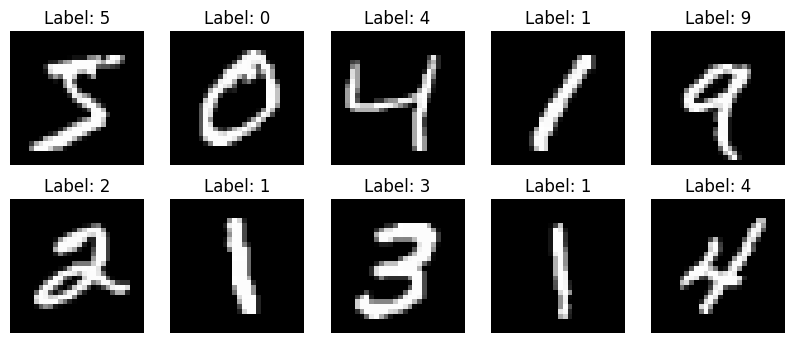

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 12, 12, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.8913 - loss: 0.3837 - val_accuracy: 0.9422 - val_loss: 0.1925
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9557 - loss: 0.1459 - val_accuracy: 0.9665 - val_loss: 0.1143
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9689 - loss: 0.0997 - val_accuracy: 0.9726 - val_loss: 0.0958
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9767 - loss: 0.0746 - val_accuracy: 0.9765 - val_loss: 0.0737
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9813 - loss: 0.0601 - val_accuracy: 0.9785 - val_loss: 0.0688
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9843 - loss: 0.0499 - val_accuracy: 0.9815 - val_loss: 0.0624
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9870 - loss: 0.0416 - val_accuracy: 0.9788 - val_loss: 0.0646
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9884 - loss: 0.0369 - val_accuracy: 

In [ ]:
#Import Necessary Libraries
import keras
import keras.utils
from keras import datasets, layers, models
from keras.models import Sequential
from keras.layers import Conv2D, AveragePooling2D, MaxPooling2D, Flatten, Dense, Activation
import matplotlib.pyplot as plt

#Load Dataset
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()

#Visualize The Training Data

plt.figure(figsize=(10, 4))  # Set The size Of The Figure
for i in range(10):
    plt.subplot(2, 5, i + 1)  # Make subplots for 10 images
    plt.imshow(x_train[i], cmap='gray')  # Display The grayscale images
    plt.title(f"Label: {y_train[i]}")  # Add labels
    plt.axis('off')  # Axis Labels Turned Off
plt.show()  # Displaying the plot


#Data Processing
#Split The Data Into Training And Validation Set
#Here, we will split the data into the training and validation set.

# Consider The First 50000 samples As The Training Dataset
x_train_main = x_train[:50000]
y_train_main = y_train[:50000]

# Conside The Last 10000 Samples AS The Validation Dataset
x_val = x_train[50000:]
y_val = y_train[50000:]


#Normalize the Data
x_train_main = x_train_main / 255.0
x_val=x_val/255.0
x_test = x_test / 255.0

#Reshape data
#Change the shape of the arrays to include the color channel of the images. Since the images are grayscale, the color channel is 1.


x_train_main = x_train_main.reshape(50000, 28, 28, 1)
x_val = x_val.reshape(10000, 28, 28, 1)
x_test = x_test.reshape(10000, 28, 28, 1)


#One Hot Encoding
#Perform one-hot encoding to convert categorical data into binary vectors.
#Each element in the binary vector corresponds to a class, and only one element is 1, while the rest are 0.
#For example, if there are 10 classes and the label is 3, the one-hot encoded vector would be [0, 0, 0, 1, 0, 0, 0, 0, 0, 0].

y_train_main = keras.utils.to_categorical(y_train_main, 10)
y_val = keras.utils.to_categorical(y_val, 10)
y_test = keras.utils.to_categorical(y_test, 10)



#Build LeNet5 Model
#Create An Instance of Sequential Class.
LeNet5_Model=Sequential()

# Add First Convolutional Layer
LeNet5_Model.add(Conv2D(6, kernel_size=(5, 5), activation='tanh', input_shape=(28, 28, 1)))

# Add First Average Pooling Layer
LeNet5_Model.add(AveragePooling2D((2, 2)))

# Add Second Convolutional Layer
LeNet5_Model.add(Conv2D(16, kernel_size=(5, 5), activation='tanh'))

# Add Second Average Pooling Layer
LeNet5_Model.add(AveragePooling2D((2, 2)))

# Flatten The Layer
LeNet5_Model.add(Flatten())

# Add Dense Layer
LeNet5_Model.add(Dense(120, activation='tanh'))
LeNet5_Model.add(Dense(84, activation='tanh'))
LeNet5_Model.add(Dense(10, activation='softmax'))

#Compile The Model
LeNet5_Model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])


#Check Model Summary
LeNet5_Model.summary()


#Train The Model
LeNet5_Model.fit(x_train_main, y_train_main, epochs=20, batch_size=128, validation_data=(x_val, y_val))


#Evaluate The Model Performance On The Test Dataset
test_loss, test_acc = LeNet5_Model.evaluate(x_test, y_test)
print('Test accuracy:', test_acc)







### LeNet with Data Augmentation
Accuracy decreases ! why ?
Because large amount of data makes it harder to process, MNIST is already good enough to achieve 99% accuracy

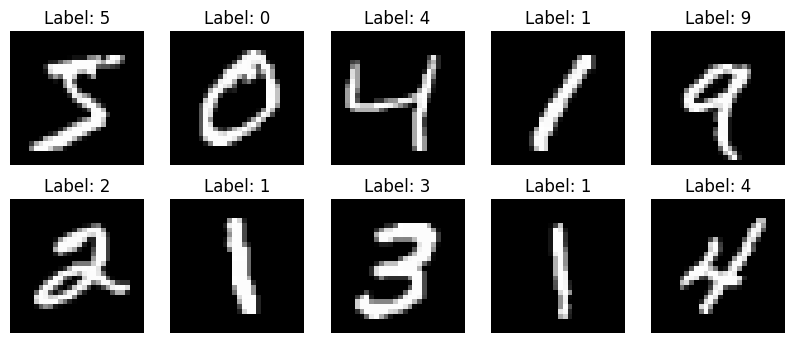

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (None, 12, 12, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_3             │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 22s 49ms/step - accuracy: 0.7297 - loss: 0.8539 - val_accuracy: 0.9334 - val_loss: 0.2230
Epoch 2/20
  1/390 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8906 - loss: 0.3966

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


390/390 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8906 - loss: 0.3966 - val_accuracy: 0.9318 - val_loss: 0.2247
Epoch 3/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - accuracy: 0.9142 - loss: 0.2850 - val_accuracy: 0.9604 - val_loss: 0.1286
Epoch 4/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9531 - loss: 0.1874 - val_accuracy: 0.9638 - val_loss: 0.1203
Epoch 5/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - accuracy: 0.9438 - loss: 0.1830 - val_accuracy: 0.9737 - val_loss: 0.0893
Epoch 6/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9219 - loss: 0.1883 - val_accuracy: 0.9727 - val_loss: 0.0920
Epoch 7/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 17s 44ms/step - accuracy: 0.9531 - loss: 0.1480 - val_accuracy: 0.9767 - val_loss: 0.0771
Epoch 8/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9609 - loss: 0.1280 - val_accuracy: 0.9762 - val_loss: 0.0775
Epoch 9/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 15s 40ms/step - accuracy: 0.9603 - loss: 0.1270 - val_accuracy: 0.981

In [ ]:
# Import Necessary Libraries
import keras
from keras import datasets
from keras.models import Sequential
from keras.layers import Conv2D, AveragePooling2D, Flatten, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# Load Dataset
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()

# Visualize Training Data
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.show()

# -------------------------------
# Data Processing
# -------------------------------

# Split into Training and Validation
x_train_main = x_train[:50000]
y_train_main = y_train[:50000]

x_val = x_train[50000:]
y_val = y_train[50000:]

# Normalize
x_train_main = x_train_main / 255.0
x_val = x_val / 255.0
x_test = x_test / 255.0

# Reshape
x_train_main = x_train_main.reshape(50000, 28, 28, 1)
x_val = x_val.reshape(10000, 28, 28, 1)
x_test = x_test.reshape(10000, 28, 28, 1)

# One-Hot Encoding
y_train_main = keras.utils.to_categorical(y_train_main, 10)
y_val = keras.utils.to_categorical(y_val, 10)
y_test = keras.utils.to_categorical(y_test, 10)

# -------------------------------
# Data Augmentation
# -------------------------------
datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

datagen.fit(x_train_main)

# -------------------------------
# Build LeNet-5 Model
# -------------------------------
model = Sequential()

# C1
model.add(Conv2D(6, kernel_size=(5, 5), activation='tanh', input_shape=(28, 28, 1)))

# S2
model.add(AveragePooling2D((2, 2)))

# C3
model.add(Conv2D(16, kernel_size=(5, 5), activation='tanh'))

# S4
model.add(AveragePooling2D((2, 2)))

# Flatten
model.add(Flatten())

# Fully Connected Layers
model.add(Dense(120, activation='tanh'))
model.add(Dense(84, activation='tanh'))
model.add(Dense(10, activation='softmax'))

# Compile
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Summary
model.summary()

# -------------------------------
# Train Model with Augmentation
# -------------------------------
batch_size = 128

history = model.fit(
    datagen.flow(x_train_main, y_train_main, batch_size=batch_size),
    steps_per_epoch=len(x_train_main) // batch_size,
    epochs=20,
    validation_data=(x_val, y_val)
)

# -------------------------------
# Evaluate Model
# -------------------------------
test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_acc)

### AlexNet

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 12, 12, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 5, 5, 384)      │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 5, 5, 384)      │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 5, 5, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │     4,198,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        40,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,767,882 (94.48 MB)

 Trainable params: 24,767,882 (94.48 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 98s 10ms/step - accuracy: 0.1108 - loss: 2.3022 - val_accuracy: 0.1135 - val_loss: 2.3014
Epoch 2/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 71s 9ms/step - accuracy: 0.1118 - loss: 2.3015 - val_accuracy: 0.1028 - val_loss: 2.3016
Epoch 3/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 75s 10ms/step - accuracy: 0.1111 - loss: 2.3015 - val_accuracy: 0.1135 - val_loss: 2.3012
Epoch 4/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 71s 9ms/step - accuracy: 0.1122 - loss: 2.3015 - val_accuracy: 0.1135 - val_loss: 2.3012
Epoch 5/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 71s 9ms/step - accuracy: 0.1121 - loss: 2.3015 - val_accuracy: 0.1135 - val_loss: 2.3014
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.1135 - loss: 2.3014
Test accuracy: 0.11349999904632568


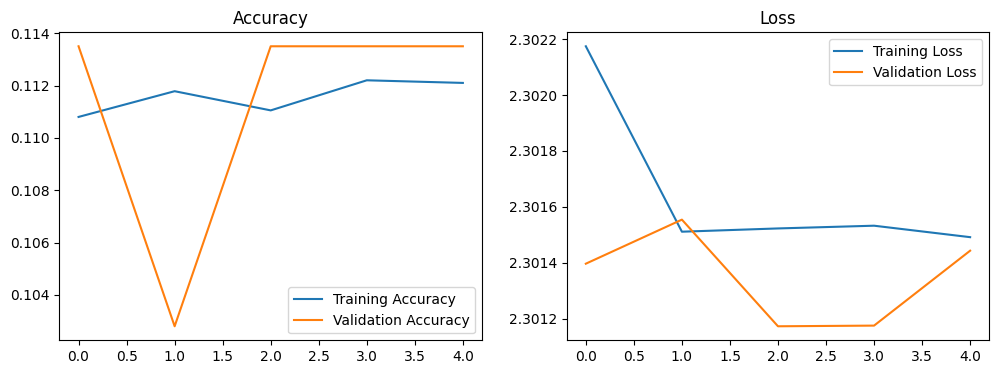

In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout
import matplotlib.pyplot as plt
import gc

# Clear previous session to free memory
keras.backend.clear_session()

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Preprocess images
x_train = tf.expand_dims(x_train, axis=-1)
x_test = tf.expand_dims(x_test, axis=-1)

# Use 112x112 instead of 224x224 (reduces memory usage)
def process_image(image, label):
    image = tf.image.grayscale_to_rgb(image)  # Convert grayscale to RGB
    image = tf.image.resize(image, (112, 112))  # Resize to 112x112
    return image / 255.0, tf.one_hot(label, 10)

# Create dataset pipeline with smaller batch size (8 or 16)
train_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_dataset = train_dataset.map(process_image).batch(8).shuffle(1000).prefetch(tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices((x_test, y_test))
test_dataset = test_dataset.map(process_image).batch(8).prefetch(tf.data.AUTOTUNE)

# Enable mixed precision (reduces memory usage)
tf.keras.mixed_precision.set_global_policy('mixed_float16')

# Build AlexNet model (with 112x112 input shape)
model = Sequential()

# Layer 1: Convolution + MaxPooling
model.add(Conv2D(96, (11, 11), strides=(4, 4), activation='relu', input_shape=(112, 112, 3)))
model.add(MaxPooling2D((3, 3), strides=(2, 2)))

# Layer 2: Convolution + MaxPooling
model.add(Conv2D(256, (5, 5), padding='same', activation='relu'))
model.add(MaxPooling2D((3, 3), strides=(2, 2)))

# Layer 3-5: Convolution Layers
model.add(Conv2D(384, (3, 3), padding='same', activation='relu'))
model.add(Conv2D(384, (3, 3), padding='same', activation='relu'))
model.add(Conv2D(256, (3, 3), padding='same', activation='relu'))
model.add(MaxPooling2D((3, 3), strides=(2, 2)))

# Flatten + Fully Connected Layers
model.add(Flatten())
model.add(Dense(4096, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(4096, activation='relu'))
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(10, activation='softmax'))

# Compile model (use Adam optimizer and mixed precision)
model.compile(optimizer=keras.optimizers.Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# Model summary
model.summary()

# Train model (with reduced batch size)
history = model.fit(train_dataset, epochs=5, validation_data=test_dataset)

# Evaluate model
test_loss, test_acc = model.evaluate(test_dataset)
print('Test accuracy:', test_acc)

# Clear memory after training
gc.collect()

# Plot Accuracy and Loss
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss')

plt.show()


### ZFNET

In [ ]:
# Import Libraries
import keras
from keras import datasets
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import matplotlib.pyplot as plt

# Load MNIST Dataset
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# Reshape (add channel dimension)
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# One-hot encoding
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

# -------------------------------
# Build ZFNet (Adapted for MNIST)
# -------------------------------
model = Sequential()

# Conv1 (ZFNet uses large filters, we reduce size)
model.add(Conv2D(32, (5,5), strides=1, activation='relu', input_shape=(28,28,1)))
model.add(MaxPooling2D(pool_size=(2,2)))

# Conv2
model.add(Conv2D(64, (3,3), activation='relu'))
# Removed MaxPooling2D(pool_size=(2,2)) here to prevent premature dimension reduction

# Conv3
model.add(Conv2D(128, (3,3), activation='relu'))

# Conv4
model.add(Conv2D(128, (3,3), activation='relu'))

# Conv5
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten
model.add(Flatten())

# Fully Connected Layers (ZFNet style)
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))

# Output
model.add(Dense(10, activation='softmax'))

# Compile
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Summary
model.summary()

# -------------------------------
# Train
# -------------------------------
history = model.fit(
    x_train, y_train,
    epochs=15,
    batch_size=128,
    validation_split=0.1
)

# -------------------------------
# Evaluate
# -------------------------------
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 24, 24, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 10, 10, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 6, 6, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 4, 4, 64)       │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 580,042 (2.21 MB)

 Trainable params: 580,042 (2.21 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 31s 44ms/step - accuracy: 0.8956 - loss: 0.3253 - val_accuracy: 0.9823 - val_loss: 0.0557
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 0.9787 - loss: 0.0750 - val_accuracy: 0.9897 - val_loss: 0.0334
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9846 - loss: 0.0527 - val_accuracy: 0.9875 - val_loss: 0.0438
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9882 - loss: 0.0415 - val_accuracy: 0.9890 - val_loss: 0.0356
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9894 - loss: 0.0365 - val_accuracy: 0.9925 - val_loss: 0.0256
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9916 - loss: 0.0287 - val_accuracy: 0.9938 - val_loss: 0.0230
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9916 - loss: 0.0289 - val_accuracy: 0.9922 - val_loss: 0.0265
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9929 - loss: 0.0242 - val_accuracy:

### VGGNet

In [ ]:
!pip install tensorflow

import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [ ]:
# Load dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Normalize pixel values (0-1)
x_train, x_test = x_train / 255.0, x_test / 255.0

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


### VGGNet

⚠️ Running on CPU/GPU


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_23 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_20 (ReLU)                 │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_21 (ReLU)                 │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_22 (ReLU)                 │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,946 (437.29 KB)

 Trainable params: 111,498 (435.54 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.4353 - loss: 1.5493 - val_accuracy: 0.2160 - val_loss: 2.5760
Epoch 2/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.5572 - loss: 1.2333 - val_accuracy: 0.5091 - val_loss: 1.3581
Epoch 3/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.6072 - loss: 1.1014 - val_accuracy: 0.5699 - val_loss: 1.2083
Epoch 4/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.6381 - loss: 1.0186 - val_accuracy: 0.6228 - val_loss: 1.0651
Epoch 5/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.6658 - loss: 0.9469 - val_accuracy: 0.5415 - val_loss: 1.3622
Epoch 6/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6831 - loss: 0.8992 - val_accuracy: 0.5337 - val_loss: 1.3462
Epoch 7/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7014 - loss: 0.8525 - val_accuracy: 0.6365 - val_loss: 1.0191
Epoch 8/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.7150 - loss: 0.8135 - val_accur

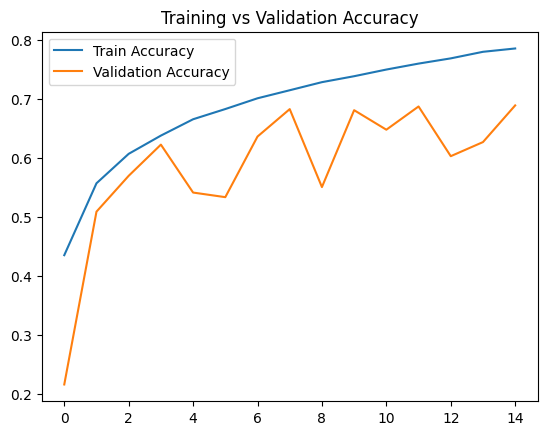

In [ ]:
# 🚀 VGGNet (Lightweight) + CIFAR-10 + TPU Support (Single Cell)

import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# ==============================
# 🔹 TPU SETUP
# ==============================
try:
    resolver = tf.distribute.cluster_resolver.TPUClusterResolver()
    tf.config.experimental_connect_to_cluster(resolver)
    tf.tpu.experimental.initialize_tpu_system(resolver)
    strategy = tf.distribute.TPUStrategy(resolver)
    print("✅ Running on TPU")
except:
    strategy = tf.distribute.get_strategy()
    print("⚠️ Running on CPU/GPU")

# ==============================
# 🔹 LOAD DATASET (CIFAR-10)
# ==============================
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Normalize
x_train, x_test = x_train / 255.0, x_test / 255.0

# ==============================
# 🔹 BUILD LIGHTWEIGHT VGG
# ==============================
def build_vgg_light(input_shape=(32,32,3), num_classes=10):
    model = models.Sequential()

    # Block 1
    model.add(layers.Conv2D(32, (3,3), padding='same', input_shape=input_shape))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.MaxPooling2D())

    # Block 2
    model.add(layers.Conv2D(64, (3,3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.MaxPooling2D())

    # Block 3
    model.add(layers.Conv2D(128, (3,3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.MaxPooling2D())

    # Classifier (LOW PARAMETERS)
    model.add(layers.GlobalAveragePooling2D())
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dropout(0.3))
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model

# ==============================
# 🔹 CREATE MODEL (INSIDE TPU SCOPE)
# ==============================
with strategy.scope():
    model = build_vgg_light()

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

model.summary()

# ==============================
# 🔹 TRAIN
# ==============================
history = model.fit(
    x_train, y_train,
    epochs=15,
    batch_size=128,
    validation_data=(x_test, y_test)
)

# ==============================
# 🔹 EVALUATE
# ==============================
test_loss, test_acc = model.evaluate(x_test, y_test)
print("✅ Test Accuracy:", test_acc)

# ==============================
# 🔹 PLOT
# ==============================
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Training vs Validation Accuracy")
plt.show()

⚠️ Running on CPU/GPU


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_20 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_17 (ReLU)                 │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_18 (ReLU)                 │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_19 (ReLU)                 │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,946 (437.29 KB)

 Trainable params: 111,498 (435.54 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.3241 - loss: 1.8548 - val_accuracy: 0.2239 - val_loss: 2.2631
Epoch 2/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4469 - loss: 1.5238 - val_accuracy: 0.4631 - val_loss: 1.4889
Epoch 3/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5052 - loss: 1.3803 - val_accuracy: 0.5178 - val_loss: 1.3410
Epoch 4/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5378 - loss: 1.2939 - val_accuracy: 0.5557 - val_loss: 1.2474
Epoch 5/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5613 - loss: 1.2345 - val_accuracy: 0.5727 - val_loss: 1.1829
Epoch 6/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5795 - loss: 1.1894 - val_accuracy: 0.5922 - val_loss: 1.1453
Epoch 7/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5920 - loss: 1.1476 - val_accuracy: 0.6050 - val_loss: 1.1024
Epoch 8/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6046 - loss: 1.1131 - val_accuracy: 

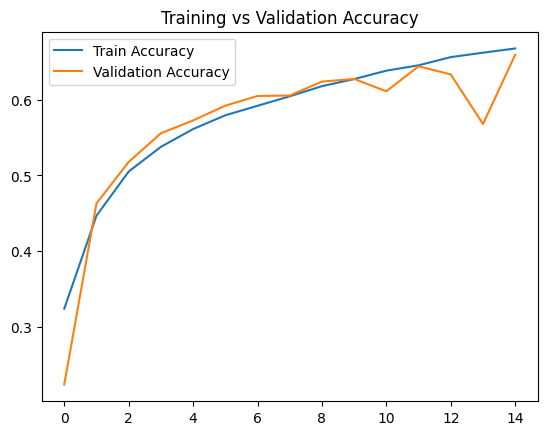

In [ ]:
# 🚀 VGGNet (Lightweight) + CIFAR-10 + TPU Support (Single Cell)

import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# ==============================
# 🔹 TPU SETUP
# ==============================
try:
    resolver = tf.distribute.cluster_resolver.TPUClusterResolver()
    tf.config.experimental_connect_to_cluster(resolver)
    tf.tpu.experimental.initialize_tpu_system(resolver)
    strategy = tf.distribute.TPUStrategy(resolver)
    print("✅ Running on TPU")
except:
    strategy = tf.distribute.get_strategy()
    print("⚠️ Running on CPU/GPU")

# ==============================
# 🔹 LOAD DATASET (CIFAR-10)
# ==============================
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Normalize
x_train, x_test = x_train / 255.0, x_test / 255.0

# ==============================
# 🔹 BUILD LIGHTWEIGHT VGG
# ==============================
def build_vgg_light(input_shape=(32,32,3), num_classes=10):
    model = models.Sequential()

    # Block 1
    model.add(layers.Conv2D(32, (3,3), padding='same', input_shape=input_shape))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.MaxPooling2D())

    # Block 2
    model.add(layers.Conv2D(64, (3,3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.MaxPooling2D())

    # Block 3
    model.add(layers.Conv2D(128, (3,3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.MaxPooling2D())

    # Classifier (LOW PARAMETERS)
    model.add(layers.GlobalAveragePooling2D())
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dropout(0.3))
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model

# ==============================
# 🔹 CREATE MODEL (INSIDE TPU SCOPE)
# ==============================
with strategy.scope():
    model = build_vgg_light()

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

model.summary()

# ==============================
# 🔹 TRAIN
# ==============================
history = model.fit(
    x_train, y_train,
    epochs=15,
    batch_size=128,
    validation_data=(x_test, y_test)
)

# ==============================
# 🔹 EVALUATE
# ==============================
test_loss, test_acc = model.evaluate(x_test, y_test)
print("✅ Test Accuracy:", test_acc)

# ==============================
# 🔹 PLOT
# ==============================
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Training vs Validation Accuracy")
plt.show()

Learning Rat 0.0005 gave mild overfitting and also the validation accuracy becomes unpredictable, reducing it to 0.0003 also does not change this, BUT
reducing it to 0.0001 makes it much better by aligning the validation and training accuracy

# Week 8

### 19 GoogLeNet

⚠️ Running on CPU/GPU


Model: "functional_16"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 32, 32,    │        896 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 16, 16,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 16, 16,    │      1,056 │ max_pooling2d_3[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 16, 16, 8) │        264 │ max_pooling2d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 16, 16,    │          0 │ max_pooling2d_3[… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 16, 16,    │      1,056 │ max_pooling2d_3[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 16,    │     13,872 │ conv2d_5[0][0]    │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 16, 16,    │      3,216 │ conv2d_7[0][0]    │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 16, 16,    │        528 │ max_pooling2d_4[… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 16, 16,    │          0 │ conv2d_4[0][0],   │
│ (Concatenate)       │ 112)              │            │ conv2d_6[0][0],   │
│                     │                   │            │ conv2d_8[0][0],   │
│                     │                   │            │ conv2d_9[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 16, 16,    │      3,616 │ concatenate[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 16, 16, 8) │        904 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 16, 16,    │          0 │ concatenate[0][0] │
│ (MaxPooling2D)      │ 112)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 16, 16,    │      5,424 │ concatenate[0][0] │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 16, 16,    │     18,496 │ conv2d_11[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_14 (Conv2D)  │ (None, 16, 16,    │      3,216 │ conv2d_13[0][0] 

 Total params: 378,986 (1.45 MB)

 Trainable params: 378,986 (1.45 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 45s 66ms/step - accuracy: 0.2989 - loss: 1.8425 - val_accuracy: 0.4313 - val_loss: 1.5308
Epoch 2/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.4575 - loss: 1.4668 - val_accuracy: 0.5168 - val_loss: 1.3109
Epoch 3/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.5282 - loss: 1.2874 - val_accuracy: 0.5751 - val_loss: 1.1632
Epoch 4/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.5811 - loss: 1.1585 - val_accuracy: 0.6108 - val_loss: 1.0736
Epoch 5/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.6170 - loss: 1.0684 - val_accuracy: 0.6199 - val_loss: 1.0425
Epoch 6/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.6431 - loss: 1.0013 - val_accuracy: 0.6577 - val_loss: 0.9578
Epoch 7/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.6660 - loss: 0.9422 - val_accuracy: 0.6693 - val_loss: 0.9352
Epoch 8/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.6858 - loss: 0.8836 - 

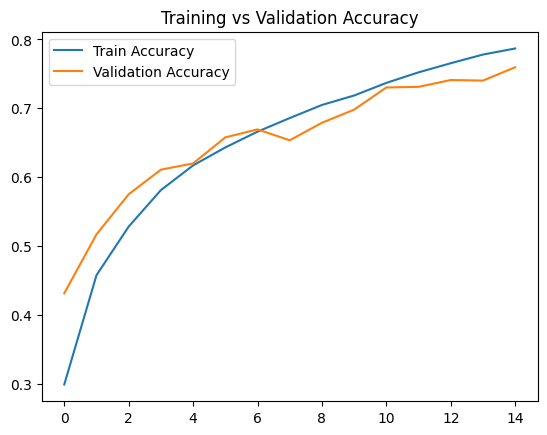

In [ ]:
# 🚀 Lightweight GoogLeNet (Inception) + CIFAR-10 + TPU (Single Cell)

import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# ==============================
# 🔹 TPU SETUP
# ==============================
try:
    resolver = tf.distribute.cluster_resolver.TPUClusterResolver()
    tf.config.experimental_connect_to_cluster(resolver)
    tf.tpu.experimental.initialize_tpu_system(resolver)
    strategy = tf.distribute.TPUStrategy(resolver)
    print("✅ Running on TPU")
except:
    strategy = tf.distribute.get_strategy()
    print("⚠️ Running on CPU/GPU")

# ==============================
# 🔹 LOAD DATASET (CIFAR-10)
# ==============================
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Normalize
x_train, x_test = x_train / 255.0, x_test / 255.0

# ==============================
# 🔹 INCEPTION MODULE (LIGHT)
# ==============================
def inception_module(x, f1, f3r, f3, f5r, f5, pool_proj):
    p1 = layers.Conv2D(f1, (1,1), padding='same', activation='relu')(x)

    p2 = layers.Conv2D(f3r, (1,1), padding='same', activation='relu')(x)
    p2 = layers.Conv2D(f3, (3,3), padding='same', activation='relu')(p2)

    p3 = layers.Conv2D(f5r, (1,1), padding='same', activation='relu')(x)
    p3 = layers.Conv2D(f5, (5,5), padding='same', activation='relu')(p3)

    p4 = layers.MaxPooling2D((3,3), strides=1, padding='same')(x)
    p4 = layers.Conv2D(pool_proj, (1,1), padding='same', activation='relu')(p4)

    return layers.concatenate([p1, p2, p3, p4], axis=-1)

# ==============================
# 🔹 BUILD LIGHTWEIGHT GOOGLENET
# ==============================
def build_googlenet_light(input_shape=(32,32,3), num_classes=10):
    inputs = layers.Input(shape=input_shape)

    x = layers.Conv2D(32, (3,3), padding='same', activation='relu')(inputs)
    x = layers.MaxPooling2D()(x)

    x = inception_module(x, 32, 32, 48, 8, 16, 16)
    x = inception_module(x, 48, 32, 64, 8, 16, 16)
    x = layers.MaxPooling2D()(x)

    x = inception_module(x, 64, 48, 96, 16, 24, 24)
    x = inception_module(x, 64, 48, 96, 16, 24, 24)
    x = layers.MaxPooling2D()(x)

    x = inception_module(x, 96, 64, 128, 16, 32, 32)

    # Classifier (LOW PARAMS)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)
    return model

# ==============================
# 🔹 CREATE MODEL (TPU SAFE)
# ==============================
with strategy.scope():
    model = build_googlenet_light()

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

model.summary()

# ==============================
# 🔹 TRAIN
# ==============================
history = model.fit(
    x_train, y_train,
    epochs=15,
    batch_size=128,
    validation_data=(x_test, y_test)
)

# ==============================
# 🔹 EVALUATE
# ==============================
test_loss, test_acc = model.evaluate(x_test, y_test)
print("✅ Test Accuracy:", test_acc)

# ==============================
# 🔹 PLOT
# ==============================
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Training vs Validation Accuracy")
plt.show()

### 20 ResNet

⚠️ Running on CPU/GPU


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 32, 32,    │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 32, 32,    │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 32, 32,    │     36,928 │ re_lu[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 32,    │     36,928 │ re_lu_1[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ re_lu[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 32, 32,    │          0 │ add[0][0]         │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 32, 32,    │     36,928 │ re_lu_2[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │     36,928 │ re_lu_3[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 32, 32,    │          0 │ batch_normalizat

 Total params: 11,188,362 (42.68 MB)

 Trainable params: 11,178,762 (42.64 MB)

 Non-trainable params: 9,600 (37.50 KB)

Epoch 1/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 95s 172ms/step - accuracy: 0.5274 - loss: 1.3208 - val_accuracy: 0.3234 - val_loss: 2.4981
Epoch 2/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 52s 134ms/step - accuracy: 0.7272 - loss: 0.7749 - val_accuracy: 0.6888 - val_loss: 0.9569
Epoch 3/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 51s 130ms/step - accuracy: 0.8009 - loss: 0.5694 - val_accuracy: 0.7516 - val_loss: 0.7425
Epoch 4/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 51s 130ms/step - accuracy: 0.8470 - loss: 0.4413 - val_accuracy: 0.6324 - val_loss: 1.2123
Epoch 5/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 51s 130ms/step - accuracy: 0.8832 - loss: 0.3367 - val_accuracy: 0.7601 - val_loss: 0.8248
Epoch 6/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 51s 130ms/step - accuracy: 0.9094 - loss: 0.2555 - val_accuracy: 0.7613 - val_loss: 0.8656
Epoch 7/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 51s 130ms/step - accuracy: 0.9333 - loss: 0.1891 - val_accuracy: 0.8113 - val_loss: 0.6793
Epoch 8/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 51s 132ms/step - accuracy: 0.9512 - loss: 0

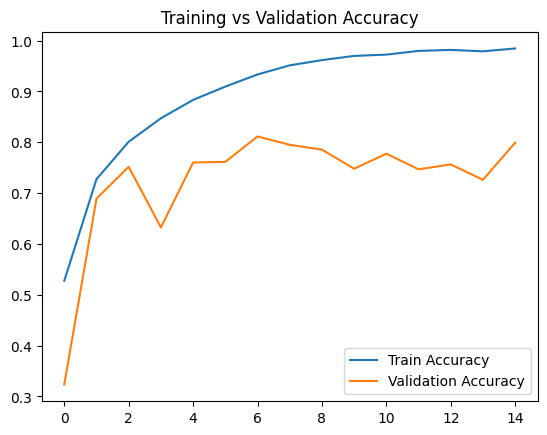

In [ ]:
# 🚀 ResNet-18 (Lightweight) + CIFAR-10 + TPU Support (Single Cell)

import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# ==============================
# 🔹 TPU SETUP
# ==============================
try:
    resolver = tf.distribute.cluster_resolver.TPUClusterResolver()
    tf.config.experimental_connect_to_cluster(resolver)
    tf.tpu.experimental.initialize_tpu_system(resolver)
    strategy = tf.distribute.TPUStrategy(resolver)
    print("✅ Running on TPU")
except:
    strategy = tf.distribute.get_strategy()
    print("⚠️ Running on CPU/GPU")

# ==============================
# 🔹 LOAD DATASET (CIFAR-10)
# ==============================
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Normalize
x_train, x_test = x_train / 255.0, x_test / 255.0

# ==============================
# 🔹 RESIDUAL BLOCK
# ==============================
def residual_block(x, filters, stride=1):
    shortcut = x

    # First Conv
    x = layers.Conv2D(filters, (3,3), strides=stride, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # Second Conv
    x = layers.Conv2D(filters, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x)

    # Adjust shortcut if needed
    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, (1,1), strides=stride, padding='same')(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    # Add skip connection
    x = layers.Add()([x, shortcut])
    x = layers.ReLU()(x)

    return x

# ==============================
# 🔹 BUILD RESNET-18
# ==============================
def build_resnet(input_shape=(32,32,3), num_classes=10):
    inputs = layers.Input(shape=input_shape)

    x = layers.Conv2D(64, (3,3), padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # Residual stages
    x = residual_block(x, 64)
    x = residual_block(x, 64)

    x = residual_block(x, 128, stride=2)
    x = residual_block(x, 128)

    x = residual_block(x, 256, stride=2)
    x = residual_block(x, 256)

    x = residual_block(x, 512, stride=2)
    x = residual_block(x, 512)

    # Classifier
    x = layers.GlobalAveragePooling2D()(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)
    return model

# ==============================
# 🔹 CREATE MODEL (TPU SAFE)
# ==============================
with strategy.scope():
    model = build_resnet()

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

model.summary()

# ==============================
# 🔹 TRAIN
# ==============================
history = model.fit(
    x_train, y_train,
    epochs=15,
    batch_size=128,
    validation_data=(x_test, y_test)
)

# ==============================
# 🔹 EVALUATE
# ==============================
test_loss, test_acc = model.evaluate(x_test, y_test)
print("✅ Test Accuracy:", test_acc)

# ==============================
# 🔹 PLOT
# ==============================
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Training vs Validation Accuracy")
plt.show()

# Week 9

### 21 CNN Feature Map Visualization

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.09MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 134kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.26MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.43MB/s]


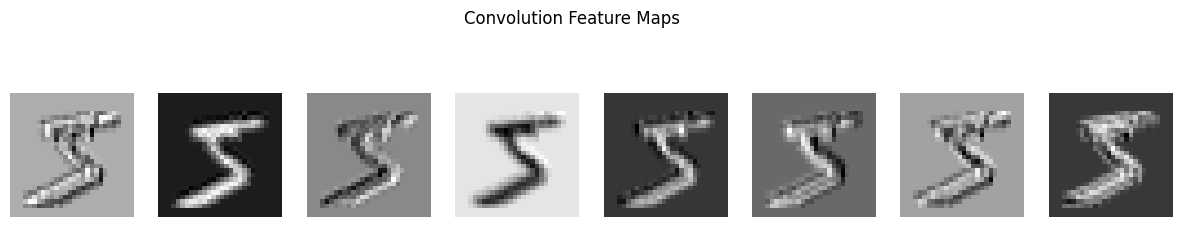

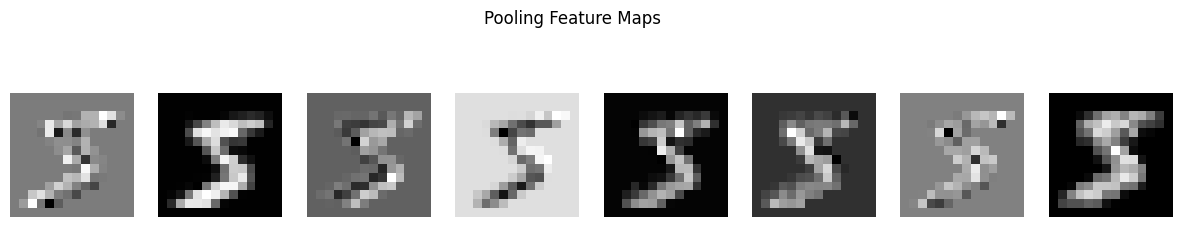

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

# Load MNIST
transform = transforms.ToTensor()
dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)

image, label = dataset[0]

# CNN Model
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(1, 8, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

    def forward(self, x):
        conv_out = self.conv(x)
        pool_out = self.pool(conv_out)
        return conv_out, pool_out

model = CNN()

# Forward pass
img = image.unsqueeze(0)
conv_out, pool_out = model(img)

# Visualization function
def plot_maps(tensor, title):
    tensor = tensor.detach().squeeze(0)
    fig, axes = plt.subplots(1, 8, figsize=(15,3))
    for i in range(8):
        axes[i].imshow(tensor[i], cmap='gray')
        axes[i].axis('off')
    plt.suptitle(title)
    plt.show()

# Show results
plot_maps(conv_out, "Convolution Feature Maps")
plot_maps(pool_out, "Pooling Feature Maps")

# Week 10

### 22 Guided Backpropagation

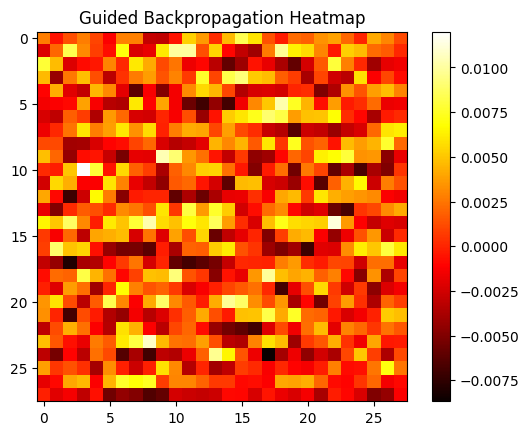

In [2]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Custom Guided ReLU
class GuidedReLU(torch.autograd.Function):
    @staticmethod
    def forward(ctx, input):
        ctx.save_for_backward(input)
        return input.clamp(min=0)

    @staticmethod
    def backward(ctx, grad_output):
        input, = ctx.saved_tensors

        grad_input = grad_output.clone()

        # Step 1: Remove negative gradients
        grad_input[grad_output < 0] = 0

        # Step 2: Remove gradients where input was negative
        grad_input[input < 0] = 0

        return grad_input


# Model with Guided ReLU
class GuidedCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(1, 1, kernel_size=3, padding=1)
        self.fc = nn.Linear(28*28, 10)

    def forward(self, x):
        x = self.conv(x)

        # Step 3: Apply Guided ReLU
        x = GuidedReLU.apply(x)

        x = x.view(-1, 28*28)
        x = self.fc(x)
        return x


model = GuidedCNN()

# Input image
img = image.unsqueeze(0)
img.requires_grad_()

# Step 4: Forward pass
output = model(img)

# Step 5: Get predicted class
pred_class = output.argmax()

# Step 6: Backprop for that class
model.zero_grad()
output[0, pred_class].backward()

# Step 7: Extract gradients
gradients = img.grad.squeeze().detach().numpy()

# Step 8: Visualization
plt.imshow(gradients, cmap='hot')
plt.title("Guided Backpropagation Heatmap")
plt.colorbar()
plt.show()

# Week 11

#### 23 Autoencoder on MNIST

Epoch 1, Loss: 0.02984590455889702
Epoch 2, Loss: 0.01659439504146576
Epoch 3, Loss: 0.011385303921997547
Epoch 4, Loss: 0.008254843764007092
Epoch 5, Loss: 0.007732274476438761


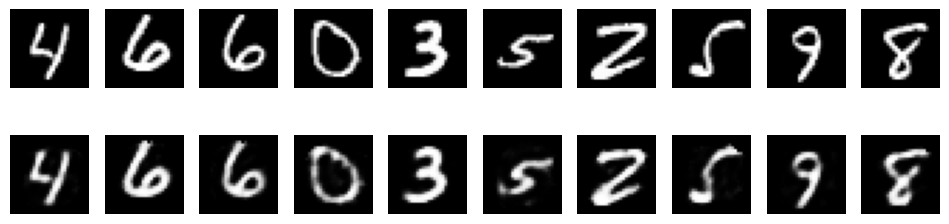

In [9]:
# BASIC AUTOENCODER (INDEPENDENT)

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load data
transform = transforms.ToTensor()
train_loader = torch.utils.data.DataLoader(
    datasets.MNIST('./data', train=True, download=True, transform=transform),
    batch_size=128, shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    datasets.MNIST('./data', train=False, transform=transform),
    batch_size=10, shuffle=True
)

# Model
class AE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(nn.Linear(784, 64), nn.ReLU())
        self.decoder = nn.Sequential(nn.Linear(64, 784), nn.Sigmoid())

    def forward(self, x):
        x = x.view(-1, 784)
        z = self.encoder(x)
        return self.decoder(z)

model = AE().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

# Train
for epoch in range(5):
    for data, _ in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, data.view(-1, 784))
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}, Loss: {loss.item()}")

# Visualize
images, _ = next(iter(test_loader))
images = images.to(device)
outputs = model(images)

images = images.cpu().view(-1,28,28)
outputs = outputs.detach().cpu().view(-1,28,28)

fig, ax = plt.subplots(2,10, figsize=(12,3))
for i in range(10):
    ax[0][i].imshow(images[i], cmap='gray'); ax[0][i].axis('off')
    ax[1][i].imshow(outputs[i], cmap='gray'); ax[1][i].axis('off')
plt.show()

### 24 Undercomplete vs Overcomplete AE

In [10]:
# UNDERCOMPLETE vs OVERCOMPLETE AE (INDEPENDENT)

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.ToTensor()
train_loader = torch.utils.data.DataLoader(
    datasets.MNIST('./data', train=True, download=True, transform=transform),
    batch_size=128, shuffle=True
)

class AE(nn.Module):
    def __init__(self, latent):
        super().__init__()
        self.encoder = nn.Sequential(nn.Linear(784, latent), nn.ReLU())
        self.decoder = nn.Sequential(nn.Linear(latent, 784), nn.Sigmoid())

    def forward(self, x):
        x = x.view(-1, 784)
        return self.decoder(self.encoder(x))

def train(model):
    model.to(device)
    opt = optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()

    for epoch in range(3):
        for data, _ in train_loader:
            data = data.to(device)
            opt.zero_grad()
            out = model(data)
            loss = loss_fn(out, data.view(-1,784))
            loss.backward()
            opt.step()
    return loss.item()

# Undercomplete
under = AE(16)
loss_under = train(under)

# Overcomplete
over = AE(256)
loss_over = train(over)

print("Undercomplete Loss:", loss_under)
print("Overcomplete Loss:", loss_over)

Undercomplete Loss: 0.032022539526224136
Overcomplete Loss: 0.0037431903183460236


### 25 Regularized Autoencoder

In [11]:
# REGULARIZED AE (INDEPENDENT)

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.ToTensor()
train_loader = torch.utils.data.DataLoader(
    datasets.MNIST('./data', train=True, download=True, transform=transform),
    batch_size=128, shuffle=True
)

class AE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(nn.Linear(784, 64), nn.ReLU())
        self.decoder = nn.Sequential(nn.Linear(64, 784), nn.Sigmoid())

    def forward(self, x):
        x = x.view(-1,784)
        return self.decoder(self.encoder(x))

model = AE().to(device)
opt = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()
lambda_reg = 1e-5

for epoch in range(5):
    for data, _ in train_loader:
        data = data.to(device)

        opt.zero_grad()
        out = model(data)

        loss = loss_fn(out, data.view(-1,784))
        l2 = sum(torch.sum(p**2) for p in model.parameters())

        total_loss = loss + lambda_reg * l2
        total_loss.backward()
        opt.step()

    print(f"Epoch {epoch+1}, Loss: {total_loss.item()}")

Epoch 1, Loss: 0.030561920255422592
Epoch 2, Loss: 0.02175177074968815
Epoch 3, Loss: 0.01926036737859249
Epoch 4, Loss: 0.017526885494589806
Epoch 5, Loss: 0.015931356698274612


### 26  Denoising Autoencoder

Epoch 1, Loss: 0.03139885514974594
Epoch 2, Loss: 0.019601134583353996
Epoch 3, Loss: 0.015873709693551064
Epoch 4, Loss: 0.01528687309473753
Epoch 5, Loss: 0.012915126979351044


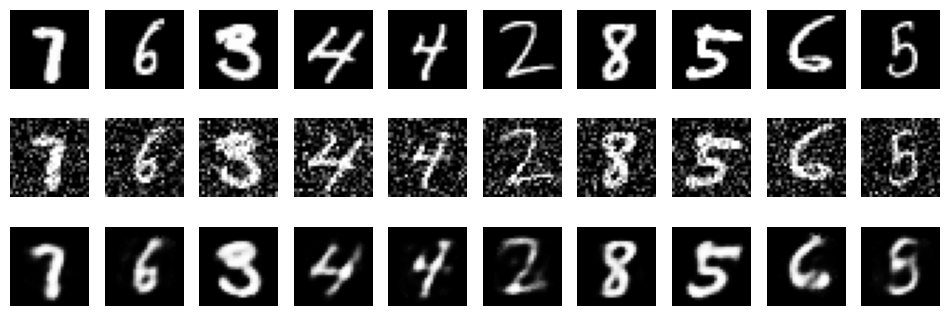

In [12]:
# DENOISING AE (INDEPENDENT)

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.ToTensor()
train_loader = torch.utils.data.DataLoader(
    datasets.MNIST('./data', train=True, download=True, transform=transform),
    batch_size=128, shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    datasets.MNIST('./data', train=False, transform=transform),
    batch_size=10, shuffle=True
)

def add_noise(x, factor=0.3):
    return torch.clamp(x + torch.randn_like(x)*factor, 0., 1.)

class AE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(nn.Linear(784,64), nn.ReLU())
        self.decoder = nn.Sequential(nn.Linear(64,784), nn.Sigmoid())

    def forward(self, x):
        x = x.view(-1,784)
        return self.decoder(self.encoder(x))

model = AE().to(device)
opt = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

# Train
for epoch in range(5):
    for data, _ in train_loader:
        data = data.to(device)
        noisy = add_noise(data, 0.3)

        opt.zero_grad()
        out = model(noisy)
        loss = loss_fn(out, data.view(-1,784))
        loss.backward()
        opt.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item()}")

# Test Visualization
images, _ = next(iter(test_loader))
noisy = add_noise(images, 0.3).to(device)

outputs = model(noisy)

images = images.view(-1,28,28)
noisy = noisy.cpu().view(-1,28,28)
outputs = outputs.detach().cpu().view(-1,28,28)

fig, ax = plt.subplots(3,10, figsize=(12,4))
for i in range(10):
    ax[0][i].imshow(images[i], cmap='gray'); ax[0][i].axis('off')
    ax[1][i].imshow(noisy[i], cmap='gray'); ax[1][i].axis('off')
    ax[2][i].imshow(outputs[i], cmap='gray'); ax[2][i].axis('off')

plt.show()

### 27 Demonstrate PCA with AE on a dataset.

Epoch 1, Loss: 0.23211635649204254
Epoch 2, Loss: 0.230294868350029
Epoch 3, Loss: 0.22806410491466522
Epoch 4, Loss: 0.22499647736549377
Epoch 5, Loss: 0.2207488715648651


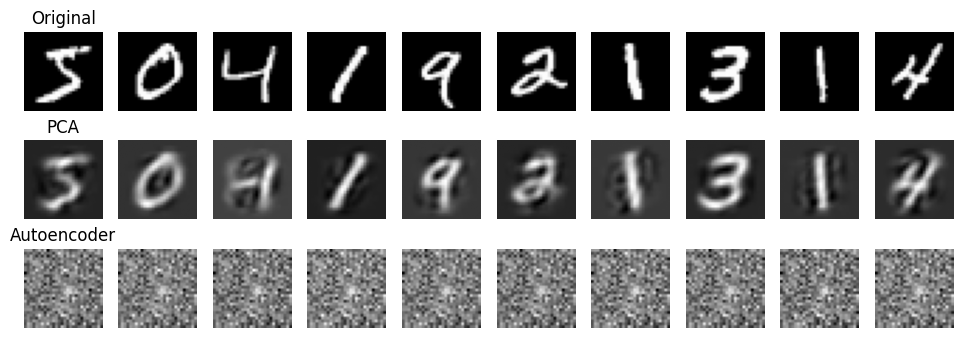

PCA Reconstruction Error: 0.016249241
AE Reconstruction Error: 0.21503729


In [13]:
# PCA vs AUTOENCODER (INDEPENDENT)

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from sklearn.decomposition import PCA
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load MNIST
transform = transforms.ToTensor()
train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)

# Take subset for speed
subset_size = 2000
data = torch.stack([train_dataset[i][0] for i in range(subset_size)])
data = data.view(subset_size, -1).numpy()

# ------------------ PCA ------------------
latent_dim = 32

pca = PCA(n_components=latent_dim)
pca_encoded = pca.fit_transform(data)
pca_reconstructed = pca.inverse_transform(pca_encoded)

# ------------------ AUTOENCODER ------------------
class AE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 784),
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

# Prepare tensor data
tensor_data = torch.tensor(data, dtype=torch.float32).to(device)

model = AE().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

# Train AE
for epoch in range(5):
    optimizer.zero_grad()
    output = model(tensor_data)
    loss = criterion(output, tensor_data)
    loss.backward()
    optimizer.step()
    print(f"Epoch {epoch+1}, Loss: {loss.item()}")

ae_reconstructed = model(tensor_data).detach().cpu().numpy()

# ------------------ Visualization ------------------
def show_results(original, pca_rec, ae_rec):
    fig, ax = plt.subplots(3, 10, figsize=(12,4))

    for i in range(10):
        ax[0][i].imshow(original[i].reshape(28,28), cmap='gray')
        ax[0][i].axis('off')

        ax[1][i].imshow(pca_rec[i].reshape(28,28), cmap='gray')
        ax[1][i].axis('off')

        ax[2][i].imshow(ae_rec[i].reshape(28,28), cmap='gray')
        ax[2][i].axis('off')

    ax[0][0].set_title("Original")
    ax[1][0].set_title("PCA")
    ax[2][0].set_title("Autoencoder")

    plt.show()

show_results(data, pca_reconstructed, ae_reconstructed)

# ------------------ Error Comparison ------------------
pca_error = np.mean((data - pca_reconstructed)**2)
ae_error = np.mean((data - ae_reconstructed)**2)

print("PCA Reconstruction Error:", pca_error)
print("AE Reconstruction Error:", ae_error)

### 28 Implement Sparse AE and Contractive AE.


#### Sparse Autoencoder (SAE)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms

# Load MNIST
transform = transforms.ToTensor()
train_loader = torch.utils.data.DataLoader(
    datasets.MNIST('./data', train=True, download=True, transform=transform),
    batch_size=128, shuffle=True)

# Sparse AE Model
class SparseAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(28*28, 256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.Sigmoid()
        )
        self.decoder = nn.Sequential(
            nn.Linear(64, 256),
            nn.ReLU(),
            nn.Linear(256, 28*28),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = x.view(-1, 28*28)
        z = self.encoder(x)
        out = self.decoder(z)
        return out, z

# KL divergence sparsity
def kl_divergence(rho, rho_hat):
    return torch.sum(rho * torch.log(rho / rho_hat) + (1 - rho) * torch.log((1 - rho)/(1 - rho_hat)))

model = SparseAE()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

rho = 0.05
beta = 1e-3

# Training
for epoch in range(5):
    for data, _ in train_loader:
        optimizer.zero_grad()
        output, hidden = model(data)

        mse_loss = criterion(output, data.view(-1, 28*28))
        rho_hat = torch.mean(hidden, dim=0)
        kl_loss = kl_divergence(rho, rho_hat)

        loss = mse_loss + beta * kl_loss
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch}, Loss: {loss.item()}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 450kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.20MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.60MB/s]


Epoch 0, Loss: 0.03397362306714058
Epoch 1, Loss: 0.02245161309838295
Epoch 2, Loss: 0.021613387390971184
Epoch 3, Loss: 0.016421588137745857
Epoch 4, Loss: 0.015373378060758114


#### Contractive Autoencoder (CAE)

In [ ]:
class ContractiveAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(784, 128),
            nn.Sigmoid()
        )
        self.decoder = nn.Sequential(
            nn.Linear(128, 784),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = x.view(-1, 784)
        z = self.encoder(x)
        out = self.decoder(z)
        return out, z

model = ContractiveAE()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()
lam = 1e-4

for epoch in range(5):
    for data, _ in train_loader:
        optimizer.zero_grad()
        output, hidden = model(data)

        mse_loss = criterion(output, data.view(-1, 784))

        # Contractive penalty
        W = model.encoder[0].weight
        dh = hidden * (1 - hidden)
        contractive_loss = torch.sum((dh ** 2) @ (W ** 2))

        loss = mse_loss + lam * contractive_loss
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch}, Loss: {loss.item()}")

Epoch 0, Loss: 0.05817939341068268
Epoch 1, Loss: 0.05139066278934479
Epoch 2, Loss: 0.045801758766174316
Epoch 3, Loss: 0.04004497826099396
Epoch 4, Loss: 0.03753818944096565


# Week 12

### 29 RNN for Next Prediction

In [ ]:
class RNNModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.rnn = nn.RNN(28, 128, batch_first=True)
        self.fc = nn.Linear(128, 10)

    def forward(self, x):
        x = x.squeeze(1)  # (B, 28, 28)
        out, _ = self.rnn(x)
        out = self.fc(out[:, -1, :])
        return out

model = RNNModel()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(5):
    for data, target in train_loader:
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch}, Loss: {loss.item()}")

Epoch 0, Loss: 0.3677428662776947
Epoch 1, Loss: 0.23131029307842255
Epoch 2, Loss: 0.24952544271945953
Epoch 3, Loss: 0.2616136372089386
Epoch 4, Loss: 0.125021830201149


### 30 LSTM & GRU

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# LSTM
class LSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(28, 128, batch_first=True)
        self.fc = nn.Linear(128, 10)

    def forward(self, x):
        x = x.squeeze(1)
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])


# GRU
class GRUModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.gru = nn.GRU(28, 128, batch_first=True)
        self.fc = nn.Linear(128, 10)

    def forward(self, x):
        x = x.squeeze(1)
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :])


def train_model(model, train_loader):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(5):
        total_loss = 0
        for data, target in train_loader:
            data, target = data.to(device), target.to(device)

            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)

            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

def test_model(model, test_loader):
    model.eval()
    correct = 0

    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            pred = output.argmax(dim=1)
            correct += (pred == target).sum().item()

    print("Accuracy:", correct / len(test_loader.dataset))


# Train & Test
lstm_model = LSTMModel()
gru_model = GRUModel()

train_model(lstm_model, train_loader)
test_model(lstm_model, train_loader)

train_model(gru_model, train_loader)
test_model(gru_model, train_loader)

Epoch 1, Loss: 289.4019
Epoch 2, Loss: 78.4325
Epoch 3, Loss: 52.5245
Epoch 4, Loss: 39.7140
Epoch 5, Loss: 32.5312
Accuracy: 0.9845166666666667
Epoch 1, Loss: 354.9172
Epoch 2, Loss: 98.0544
Epoch 3, Loss: 61.3097
Epoch 4, Loss: 45.5064
Epoch 5, Loss: 35.8345
Accuracy: 0.9798


### 31 Encoder–Decoder Model (Sequence Reconstruction)

In [ ]:
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(28, 128, batch_first=True)

    def forward(self, x):
        _, (h, c) = self.lstm(x)
        return h, c


class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(28, 128, batch_first=True)
        self.fc = nn.Linear(128, 28)

    def forward(self, x, h, c):
        out, _ = self.lstm(x, (h, c))
        return self.fc(out)


class Seq2Seq(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = Encoder()
        self.decoder = Decoder()

    def forward(self, x):
        x = x.squeeze(1)
        h, c = self.encoder(x)
        out = self.decoder(x, h, c)
        return out


model = Seq2Seq().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

# Training
for epoch in range(5):
    total_loss = 0
    for data, _ in train_loader:
        data = data.to(device)
        data_seq = data.squeeze(1)

        optimizer.zero_grad()
        output = model(data)

        loss = criterion(output, data_seq)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 4.5601
Epoch 2, Loss: 0.0826
Epoch 3, Loss: 0.0138
Epoch 4, Loss: 0.0097
Epoch 5, Loss: 0.0079


### 32 Attention Mechanism

In [ ]:
class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()

    def forward(self, hidden, encoder_outputs):
        scores = torch.bmm(encoder_outputs, hidden.unsqueeze(2)).squeeze(2)
        weights = torch.softmax(scores, dim=1)
        context = torch.bmm(weights.unsqueeze(1), encoder_outputs)
        return context.squeeze(1)


class AttentionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(28, 128, batch_first=True)
        self.attn = Attention(128)
        self.fc = nn.Linear(128, 10)

    def forward(self, x):
        x = x.squeeze(1)
        outputs, (h, _) = self.lstm(x)
        context = self.attn(h[-1], outputs)
        return self.fc(context)


model = AttentionModel().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

# Training
for epoch in range(5):
    total_loss = 0
    for data, target in train_loader:
        data, target = data.to(device), target.to(device)

        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)

        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

# Testing
test_model(model, train_loader)

Epoch 1, Loss: 348.7789
Epoch 2, Loss: 84.9967
Epoch 3, Loss: 54.4019
Epoch 4, Loss: 40.9226
Epoch 5, Loss: 32.7573
Accuracy: 0.9815833333333334
